# Numerical Eigenstates of the Quantum Harmonic Oscillator

This notebook calculates the lowest energy levels of the one-dimensional harmonic oscillator and compares them with the analytic result. A sparse eigensolver is used because only the lowest few states are needed.

Using dimensionless units,
\[
\hbar=m=\omega=1,
\]
the Hamiltonian becomes
\[
H=-\frac{1}{2}\frac{d^2}{dx^2}+\frac{1}{2}x^2,
\]
and the exact energy levels are
\[
E_n=n+\frac{1}{2}.
\]

## Numerical setup

The calculation uses \(x\in[-8,8]\) with \(N=1000\) grid points and Dirichlet boundary conditions,
\[
\psi(-8)=\psi(8)=0.
\]

The second derivative is approximated by
\[
\frac{d^2\psi}{dx^2}\bigg|_{x_i}
\approx
\frac{\psi_{i+1}-2\psi_i+\psi_{i-1}}{\Delta x^2}.
\]

This gives a real symmetric tridiagonal Hamiltonian.

## Eigensolver

I used `scipy.sparse.linalg.eigsh` because the Hamiltonian is symmetric and stored as a sparse matrix. Since only the lowest few energy levels are needed, calculating the full spectrum would be unnecessary. The option `which="SA"` returns the smallest eigenvalues.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh

# Show more digits in the table
pd.set_option("display.precision", 10)

In [2]:
# Dimensionless parameters
hbar = 1.0
mass = 1.0
omega = 1.0

# Numerical parameters
L = 8.0
N = 1000
num_states = 6

# Include the two boundary points
x_full = np.linspace(-L, L, N)
dx = x_full[1] - x_full[0]

# The endpoint values are fixed at zero, so solve only for interior points.
x = x_full[1:-1]
M = x.size

print(f"Interval: [{-L}, {L}]")
print(f"Total grid points: {N}")
print(f"Interior unknowns: {M}")
print(f"Grid spacing dx: {dx:.10f}")

Interval: [-8.0, 8.0]
Total grid points: 1000
Interior unknowns: 998
Grid spacing dx: 0.0160160160


In [3]:
# Centered finite difference for the second derivative
lower = np.ones(M - 1)
main = -2.0 * np.ones(M)
upper = np.ones(M - 1)

D2 = diags(
    diagonals=[lower, main, upper],
    offsets=[-1, 0, 1],
    shape=(M, M),
    format="csr",
) / dx**2

# Harmonic oscillator potential
V = 0.5 * x**2

# Hamiltonian in dimensionless units
H = -0.5 * D2 + diags(V, offsets=0, format="csr")

print(f"Hamiltonian shape: {H.shape}")
print(f"Stored nonzero entries: {H.nnz}")

Hamiltonian shape: (998, 998)
Stored nonzero entries: 2992


In [4]:
# Lowest six eigenpairs
energies_num, states = eigsh(H, k=num_states, which="SA")

# Sort by energy
order = np.argsort(energies_num)
energies_num = energies_num[order]
states = states[:, order]

# Normalize each wavefunction
for j in range(num_states):
    norm = np.sqrt(np.trapezoid(np.abs(states[:, j])**2, x))
    states[:, j] /= norm

energies_num

array([0.49999198, 1.49995992, 2.49989579, 3.49979959, 4.49967132,
       5.49951098])

In [5]:
n = np.arange(num_states)
energies_exact = n + 0.5
absolute_difference = np.abs(energies_num - energies_exact)
relative_difference_percent = 100.0 * absolute_difference / energies_exact

comparison = pd.DataFrame({
    "n": n,
    "Numerical energy": energies_num,
    "Analytic energy": energies_exact,
    "Absolute difference": absolute_difference,
    "Relative difference (%)": relative_difference_percent,
})

comparison

,n,Numerical energy,Analytic energy,Absolute difference,Relative difference (%)
0,0,0.4999919838,0.5,0.0000080162,0.0016032305
1,1,1.4999599187,1.5,0.0000400813,0.0026720851
2,2,2.4998957872,2.5,0.0001042128,0.0041685124
3,3,3.4997995877,3.5,0.0002004123,0.0057260656
4,4,4.4996713187,4.5,0.0003286813,0.0073040284
5,5,5.4995109787,5.5,0.0004890213,0.0088912963


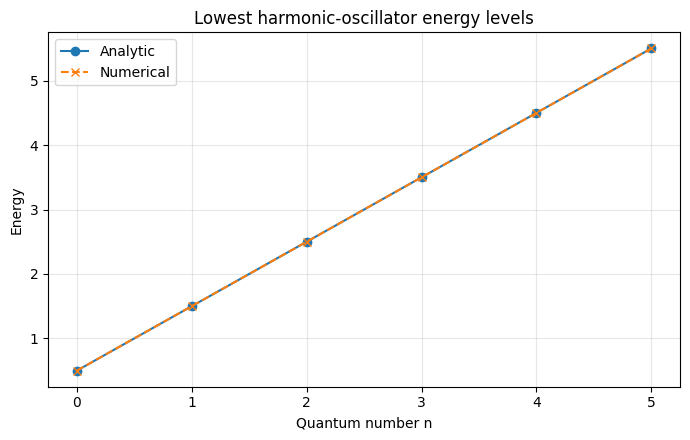

In [6]:
# Compare numerical and analytic energies
plt.figure(figsize=(7, 4.5))
plt.plot(n, energies_exact, "o-", label="Analytic")
plt.plot(n, energies_num, "x--", label="Numerical")
plt.xlabel("Quantum number n")
plt.ylabel("Energy")
plt.title("Lowest harmonic-oscillator energy levels")
plt.xticks(n)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Check normalization and orthogonality
overlap = states.T.conj() @ states * dx
max_normalization_error = np.max(np.abs(np.diag(overlap) - 1.0))
max_off_diagonal_overlap = np.max(np.abs(overlap - np.eye(num_states)))

print(f"Maximum normalization error: {max_normalization_error:.3e}")
print(f"Maximum orthogonality error: {max_off_diagonal_overlap:.3e}")
print(f"Largest absolute energy difference: {absolute_difference.max():.3e}")

Maximum normalization error: 2.309e-14
Maximum orthogonality error: 2.309e-14
Largest absolute energy difference: 4.890e-04


## Result

The numerical energies are very close to the exact values. The small remaining differences come from the finite grid spacing and the finite interval used in the calculation.